# Aktivitet: Kanonen – prosjektilbevegelse
**TRES0312 Fysikk — Kapittel 3: Kinematikk (Forelesning 6)**

En kanon skyter en kule fra en høyde $y_0$ over bakken, med en vinkel $\theta$ i forhold til horisontalen og utgangsfart $v_0$. Vi regner ut og tegner banen kula følger, uten å ta hensyn til luftmotstand.

Bevegelsen er summen av to uavhengige bevegelser:
- Horisontalt: konstant fart, $v_x = v_0\cos\theta$
- Vertikalt: konstant akselerasjon $-g$, med startfart $v_y = v_0\sin\theta$

$$x(t) = v_x\,t, \qquad y(t) = y_0 + v_y\,t - \tfrac{1}{2}g\,t^2$$

Nedenfor beregner vi flytid, landingsavstand og makshøyde, og tegner banen.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parametere (fra aktiviteten "Kanonen")
# -------------------------
vinkel = 60.0   # utskytingsvinkel [grader]
v0 = 4.84       # utgangsfart [m/s]
y0 = 0.25       # starthøyde over bakken [m]
g = 9.81        # tyngdeakselerasjon [m/s^2]

In [17]:
def prosjektilbane(vinkel, v0, y0=0.0, g=9.81, antall_punkter=500):
    """
    Beregner prosjektilbanen (uten luftmotstand) fra utskyting til
    prosjektilet treffer bakken igjen (y = 0).

    Parametere
    ----------
    vinkel : utskytingsvinkel i grader, malt fra horisontalen
    v0 : utgangsfart [m/s]
    y0 : starthoyde over bakken [m]
    g : tyngdeakselerasjon [m/s^2]
    antall_punkter : antall punkter banen beregnes i (for plotting)

    Returnerer
    ----------
    dict med tidsvektor, posisjon (x, y) og nokkeltall for banen.
    """
    theta = np.radians(vinkel)
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    # Flytiden er den positive losningen av andregradslikningen
    #   y0 + vy*t - 0.5*g*t**2 = 0
    flytid = (vy + np.sqrt(vy**2 + 2 * g * y0)) / g
    landingsavstand = vx * flytid

    t = np.linspace(0, flytid, antall_punkter)
    x = vx * t
    y = y0 + vy * t - 0.5 * g * t**2

    # Toppunktet nas nar den vertikale farten er null
    tid_til_topp = vy / g
    makshoyde = y0 + vy**2 / (2 * g)
    x_topp = vx * tid_til_topp

    return {
        "t": t,
        "x": x,
        "y": y,
        "flytid": flytid,
        "landingsavstand": landingsavstand,
        "makshoyde": makshoyde,
        "x_topp": x_topp,
        "tid_til_topp": tid_til_topp,
    }

In [14]:
resultat = prosjektilbane(vinkel, v0, y0, g)

etiketter_verdier = [
    ("Vinkel:", f"{vinkel:.2f}\u00b0"),
    ("Utgangshastighet:", f"{v0:.2f} m/s"),
    ("Starthoyde:", f"{y0:.2f} m"),
    ("Flytid:", f"{resultat['flytid']:.3f} s"),
    ("Maksimal hoyde:", f"{resultat['makshoyde']:.3f} m"),
    ("Landingsavstand:", f"{resultat['landingsavstand']:.3f} m"),
]
for etikett, verdi in etiketter_verdier:
    print(f"{etikett:<20}{verdi}")

Vinkel:             60.00°
Utgangshastighet:   4.84 m/s
Starthoyde:         0.25 m
Flytid:             0.911 s
Maksimal hoyde:     1.145 m
Landingsavstand:    2.203 m


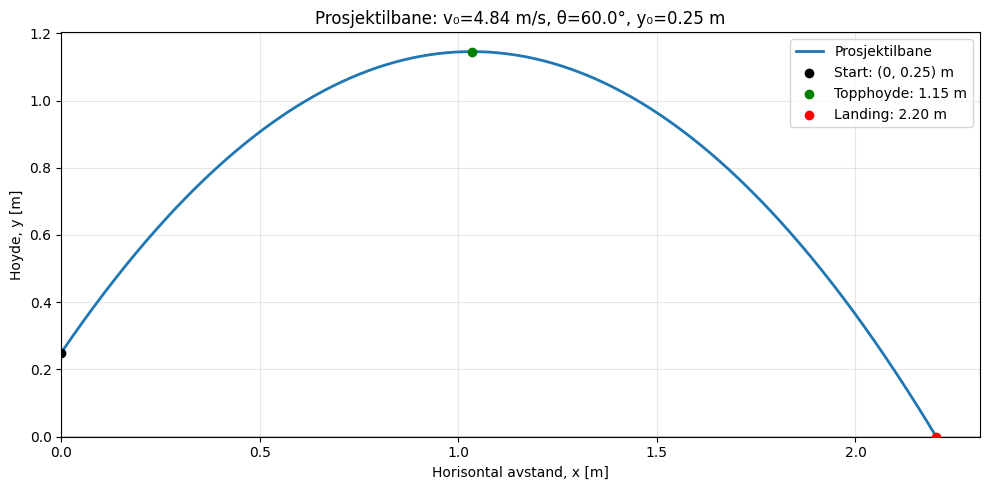

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(resultat["x"], resultat["y"], linewidth=2, label="Prosjektilbane")

plt.scatter(0, y0, color="black", zorder=3, label=f"Start: (0, {y0:.2f}) m")
plt.scatter(
    resultat["x_topp"], resultat["makshoyde"],
    color="green", zorder=3,
    label=f"Topphoyde: {resultat['makshoyde']:.2f} m",
)
plt.scatter(
    resultat["landingsavstand"], 0,
    color="red", zorder=3,
    label=f"Landing: {resultat['landingsavstand']:.2f} m",
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Horisontal avstand, x [m]")
plt.ylabel("Hoyde, y [m]")
plt.title(
    f"Prosjektilbane: v\u2080={v0:.2f} m/s, "
    f"\u03b8={vinkel:.1f}\u00b0, y\u2080={y0:.2f} m"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Prøv selv
- Endre `vinkel`, `v0` eller `y0` øverst og kjør cellene på nytt. Hvordan endrer landingsavstanden og makshøyden seg?
- Hvilken vinkel gir lengst landingsavstand når $y_0 = 0$? Prøv noen ulike vinkler og sammenlign.
- Modellen ser bort fra luftmotstand. Hvordan tror du en reell kanonkule ville avveket fra denne banen?